## What this Notebook Does

This notebook analyses monthly exposure of vulnerable populations to health-relevant hazard combinations using precomputed impact objects.

---

### Input
- Impact objects containing the **number of people exposed per month**, at each grid point, for various **hazard combinations** and **age categories**.

---

### Workflow

1. **Select a subset of hazard combinations** (e.g. heatwaves, heat + drought) and **plot**:
   - The **number of months** during which people at each grid point were exposed.
   - Results are shown as **global gridded maps**, not aggregated by admin regions.

2. **Plot all available hazard combinations**:
   - One subplot per combination.
   - Values reflect how often exposure occurred per grid point.

3. **Compare two time periods** (e.g. 2003–2012 vs. 2013–2021) for each hazard combination:
   - The resulting plots show the **change in exposure frequency** at each grid point.
   - Colour indicates whether exposure has increased or decreased.
   - Only combinations with substantial exposure (e.g. >1 million people) are plotted.

4. **Compute summary statistics**:
   - Calculate the **average number of months** with exposure **per age category** and **per hazard combination**.
   - Useful to identify which combinations affect which age groups the most on average.

---

### Output
- Gridded global maps showing:
  - **Total number of months** with exposure per grid cell
  - **Change in frequency of exposure** between two time periods
- A **summary table or array** of mean exposure values by **age group** and **hazard combination**

All maps are visualised using a **Robinson projection** and colour scales are adjusted to emphasise relevant patterns (e.g. capped percentiles, diverging colours for changes).


In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../exposure_to_hazards/')

from config import FIGURES, DATA_DIR, FIGURES_SI
from pathlib import Path


Which country has the highest number of vulnerable (below 1 or over 65) people that have been exposed on average per month to any health hazard relative to the total population?

In [2]:
from pathlib import Path
import itertools
from climada.engine import Impact

combinations = []

hazards = ['RF', 'EP', 'DR', 'HW', 'FI', 'TC']  # Keep 'FI' for file names

for r in range(1, len(hazards) + 1):
    combinations.extend(list(itertools.combinations(hazards, r)))

combinations = ["-".join(combi) for combi in combinations]

IMPACT_DIR = DATA_DIR / "impacts"

imp_combined = {}
for age in ['all', '0_1', '65_70_75_80']:
    imp_combined[age] = {}
    for combi in combinations:
        # Create the dictionary key with 'FI' replaced by 'WF'
        dict_key = combi.replace('FI', 'WF')
        
        imp_combined[age][dict_key] = Impact.from_csv(IMPACT_DIR / f"csv/{combi}_{age}_2003_2022.csv")
        imp_combined[age][dict_key].imp_mat = Impact.read_sparse_csr(IMPACT_DIR / f"npz/{combi}_{age}_2003_2022.npz")
        imp_combined[age][dict_key]


2025-06-13 11:35:56,170 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-13 11:35:56,675 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-13 11:35:57,204 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


...

/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-13 11:37:15,209 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-13 11:37:15,625 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


In [3]:
from pathlib import Path
from climada.entity import Exposures
import numpy as np
import pandas as pd

exposures_dict = {}
path_population_files = DATA_DIR / "population"

path_exposures = path_population_files / "worldpop/climada_exposures"
total_pop = {}
exposures_dict = {}
for age in ["0_1", "all", "65_70_75_80"]:
    total_pop[age] = {}
    exposures_dict[age]= {}
    for year in np.arange(2003, 2023):
        year = str(year)
        exposures_dict[age][year]= Exposures.from_hdf5(path_exposures / f"{age}_era5_025_compatible_{year}.hdf5")
        exposures_dict[age][year].gdf["impf_cs"] = 1 
        exposures_dict[age][year].gdf['value'][exposures_dict[age][year].gdf['value']<0] = 0
        total_pop[age][year] = exposures_dict[age][year].gdf['value'].sum()

In [4]:
three_tuple_keys = [key for key in imp_combined['all'].keys() if len(key) == 8]
single_tuple_keys = [key for key in imp_combined[age].keys() if len(key == 2]
double_tuple_keys = [key for key in imp_combined[age].keys() if len(key == 5]


imp_combined_three_hazards = {
    age: {
        key: imp_combined[age][key]
        for key in three_tuple_keys
        if imp_combined[age][key].imp_mat.nnz > 0
    }
    for age in imp_combined
}

imp_combined_one_hazard = {
    age: {
        key: imp_combined[age][key]
        for key in single_tuple_keys
        if imp_combined[age][key].imp_mat.nnz > 0
    }
    for age in imp_combined
}

imp_combined_two_hazard = {
    age: {
        key: imp_combined[age][key]
        for key in double_tuple_keys
        if imp_combined[age][key].imp_mat.nnz > 0
    }
    for age in imp_combined
}

In [5]:
from multi_risk_methods import *

at_least_three_hazards = {}
for age in imp_combined:
    at_least_three_hazards[age] = combine_impacts(imp_combined_three_hazards[age], how="max")

at_least_one_hazards = {}
for age in imp_combined:
    at_least_one_hazards[age] = combine_impacts(imp_combined_one_hazard[age], how="max")

at_least_two_hazards = {}
for age in imp_combined:
    at_least_two_hazards[age] = combine_impacts(imp_combined_two_hazard[age], how="max")

In [6]:
total_pop

{'0_1': {'2003': 597582544.9874045,
  '2004': 599170589.3891324,
  '2005': 602245266.6836045,
  '2006': 607632995.5170199,
  '2007': 612840089.6240511,
  '2008': 617269140.7664213,
  '2009': 623059548.6696811,
  '2010': 629709312.6437539,
  '2011': 635928978.3512176,
  '2012': 642812624.6307214,
  '2013': 649245083.5859689,
  '2014': 655119014.1083949,
  '2015': 661003823.429653,
  '2016': 670408162.2809194,
  '2017': 677130894.4494472,
  '2018': 682950082.2526637,
  '2019': 688493456.5129743,
  '2020': 694036895.2121024,
  '2021': 699595741.9339635,
  '2022': 705140657.9862735},
 'all': {'2003': 6231476680.472461,
  '2004': 6305452795.492844,
  '2005': 6383573393.800345,
  '2006': 6463220929.117003,
  '2007': 6545806956.102976,
  '2008': 6631416874.626957,
  '2009': 6720167524.091269,
  '2010': 6812530932.263073,
  '2011': 6909003520.87335,
  '2012': 7007930991.639009,
  '2013': 7110649219.040524,
  '2014': 7216992786.41943,
  '2015': 7330048570.100435,
  '2016': 7445749063.887413,
  

In [7]:
import pandas as pd

total_impact_per_person = {}
for age in ['all', '0_1', '65_70_75_80']:
    total_impact_per_person[age] = {}
    for combi in imp_combined[age]:
        total_months = imp_combined[age][combi].imp_mat.shape[0]
        total_impact_per_person[age][combi] = np.sum([imp_combined[age][combi].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,int(total_months/12))])
    total_impact_per_person[age]['Three or more'] = np.sum([at_least_three_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,int(total_months/12))])
    total_impact_per_person[age]['Two or more'] = np.sum([at_least_two_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,int(total_months/12))])
    total_impact_per_person[age]['One or more'] = np.sum([at_least_one_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,int(total_months/12))])

df = pd.DataFrame(total_impact_per_person)
df = df[df.sum(axis=1)>0.01]
index_order = list(df.index)


In [8]:
total_impact_per_person_period1 = {}
for age in ['all', '0_1', '65_70_75_80']:
    total_impact_per_person_period1[age] = {}
    for combi in imp_combined[age]:
        total_months = imp_combined[age][combi].imp_mat.shape[0]
        total_impact_per_person_period1[age][combi] = np.sum([imp_combined[age][combi].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,11)])
        total_impact_per_person_period1[age]['Three or more'] = np.sum([at_least_three_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,11)])
        total_impact_per_person_period1[age]['Two or more'] = np.sum([at_least_two_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,11)])

        total_impact_per_person_period1[age]['One or more'] = np.sum([at_least_one_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(1,11)])


df1 = pd.DataFrame(total_impact_per_person_period1)
df1 = df1.reindex(index_order)
#df1= df1[df1.sum(axis=1)>0]


In [9]:
total_impact_per_person_period2 = {}
for age in ['all', '0_1', '65_70_75_80']:
    total_impact_per_person_period2[age] = {}
    for combi in imp_combined[age]:
        total_months = imp_combined[age][combi].imp_mat.shape[0]
        total_impact_per_person_period2[age][combi] = np.sum([imp_combined[age][combi].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(10,20)])
        total_impact_per_person_period2[age]['Three or more'] = np.sum([at_least_three_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(10,20)])
        total_impact_per_person_period2[age]['Two or more'] = np.sum([at_least_two_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(10,20)])

        total_impact_per_person_period2[age]['One or more'] = np.sum([at_least_one_hazards[age].imp_mat[n*12-12:n*12].sum()/total_pop[age][str(n + 2003)] for n in range(10,20)])

df2 = pd.DataFrame(total_impact_per_person_period2)
df2 = df2.reindex(index_order)
df1 = df1.round(3)
#df2= df2[df2.sum(axis=1)>0]


In [10]:
df_diff = 100*(df2-df1)/df1
df_diff = df_diff.reindex(index_order)
df_diff = df_diff.rename(index=lambda x: x.replace('RF_2y', 'RF'))
df_diff = df_diff.dropna()

In [11]:
combis = ['HW',
 'DR-HW',
 'HW-WF',
 'DR-HW-WF',
 'Three or more',
 'RF',
 'EP',
 'DR',
 'WF',
 'TC',
 'RF-EP',
 'RF-DR',
 'RF-HW',
 'RF-TC',
 'EP-DR',
 'EP-HW',
 'EP-WF',
 'EP-TC',
 'DR-WF',
 'DR-TC',
 'HW-TC',
 'RF-EP-DR',
 'RF-EP-HW',
 'RF-EP-TC',
 'RF-HW-TC',
 'EP-DR-HW',
 'EP-HW-WF',
 'EP-HW-TC',
 'One or more',
 'Two or more',
 'Three or more']
df  = pd.concat([df,df_diff],axis=1)
df = df.round(3)

df[df.index.isin(combis)]

,all,0_1,65_70_75_80,all,0_1,65_70_75_80
RF,1.064,1.060,0.999,-5.407,-10.004,-0.853
EP,6.361,6.678,6.111,10.379,13.925,6.306
DR,5.135,5.294,4.707,-3.114,-2.322,-6.988
HW,18.638,17.448,19.997,31.536,36.893,25.663
WF,0.754,0.940,0.622,-1.419,-1.037,-0.616
TC,0.300,0.222,0.511,-9.637,-12.749,0.478
RF-EP,0.200,0.201,0.172,8.968,6.659,16.668
RF-DR,0.014,0.018,0.009,-12.358,-22.008,-16.194
RF-HW,0.131,0.094,0.152,11.184,5.028,23.388
RF-TC,0.005,0.004,0.007,-18.758,-9.256,-12.604


In [12]:
exp = exposures_dict[age]['2003']
imp_mat = imp_combined[age]['WF'].imp_mat[0:12]
m1 = imp_combined[age]['WF'].imp_mat[0:12].data
m2 = np.array(exp.gdf.value[imp_mat.nonzero()[1]])
np.sum(m1>m2)

0

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/2380210841.py:10: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


[]

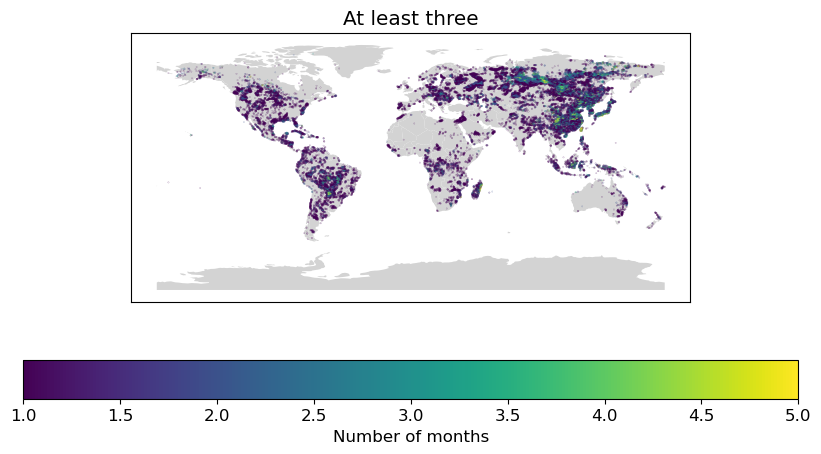

In [13]:
import copy
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})  # You can adjust the size as needed

pair_tuple_keys = [key for key in imp_combined[age].keys() if len(key) == 5]

# Load a world map to use as a land mask
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


gdf =at_least_three_hazards[age]._build_exp().gdf
imp_mat = copy.deepcopy(at_least_three_hazards[age].imp_mat)
imp_mat.data[imp_mat.data < 1] = 0
imp_mat.data[imp_mat.data >= 1] = 1


gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]
#gdf['geometry'] = gpd.points_from_xy(gdf.longitude, gdf.latitude)

# Determine dynamic vmax
vmax = gdf['value'][gdf['value']>0].quantile(0.99)  # Set vmax to the 95th percentile of the data

# Plot the world map with only the land areas colored

# Overlay the geodataframe with the values
gdf.value[gdf.value==0] = np.nan
if vmax==0:
    vmax=2
fig, ax = plt.subplots(figsize=(10, 5))
world.plot(ax=ax, color='lightgrey')
gdf['value'][gdf['value']>0] = gdf['value'][gdf['value']>0].astype(int)
gdf.plot(column='value', ax=ax, markersize=0.01, cmap='viridis', vmin=1, vmax=vmax)
cbar = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=1, vmax=vmax))
ax_cbar = fig.colorbar(cbar, ax=ax, orientation='horizontal') 
ax_cbar.set_label(f'Number of months', fontsize=12)

# Set plot title and labels
ax.set_title(f'At least three')

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  
#plt.savefig(FIGURES / f"nmonth_{combi}.png", bbox_inches='tight', dpi=1200)

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/2944506508.py:10: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


[]

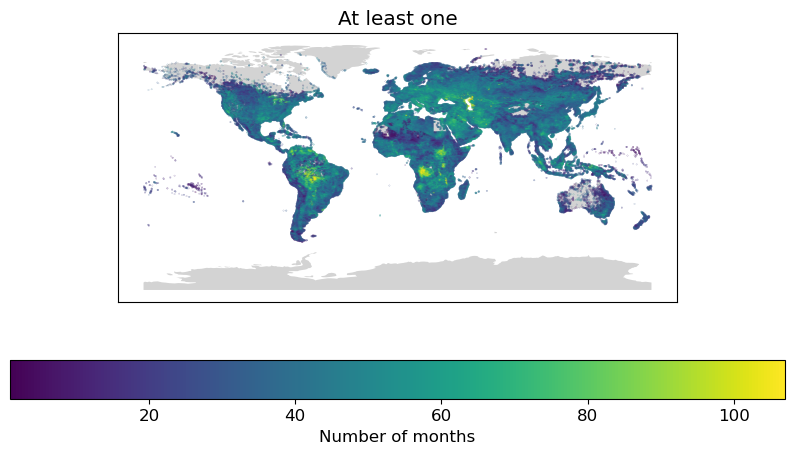

In [14]:
import copy
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})  # You can adjust the size as needed

pair_tuple_keys = [key for key in imp_combined[age].keys() if len(key) == 5]

# Load a world map to use as a land mask
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


gdf =at_least_one_hazards[age]._build_exp().gdf
imp_mat = copy.deepcopy(at_least_one_hazards[age].imp_mat)
imp_mat.data[imp_mat.data < 1] = 0
imp_mat.data[imp_mat.data >= 1] = 1


gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]
#gdf['geometry'] = gpd.points_from_xy(gdf.longitude, gdf.latitude)

# Determine dynamic vmax
vmax = gdf['value'][gdf['value']>0].quantile(0.999)  # Set vmax to the 95th percentile of the data

# Plot the world map with only the land areas colored

# Overlay the geodataframe with the values
gdf.value[gdf.value==0] = np.nan
if vmax==0:
    vmax=2
fig, ax = plt.subplots(figsize=(10, 5))
world.plot(ax=ax, color='lightgrey')
gdf['value'][gdf['value']>0] = gdf['value'][gdf['value']>0].astype(int)
gdf.plot(column='value', ax=ax, markersize=0.01, cmap='viridis', vmin=1, vmax=vmax)
cbar = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=1, vmax=vmax))
ax_cbar = fig.colorbar(cbar, ax=ax, orientation='horizontal') 
ax_cbar.set_label(f'Number of months', fontsize=12)

# Set plot title and labels
ax.set_title(f'At least one')

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  
#plt.savefig(FIGURES / f"nmonth_{combi}.png", bbox_inches='tight', dpi=1200)

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/171840725.py:16: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


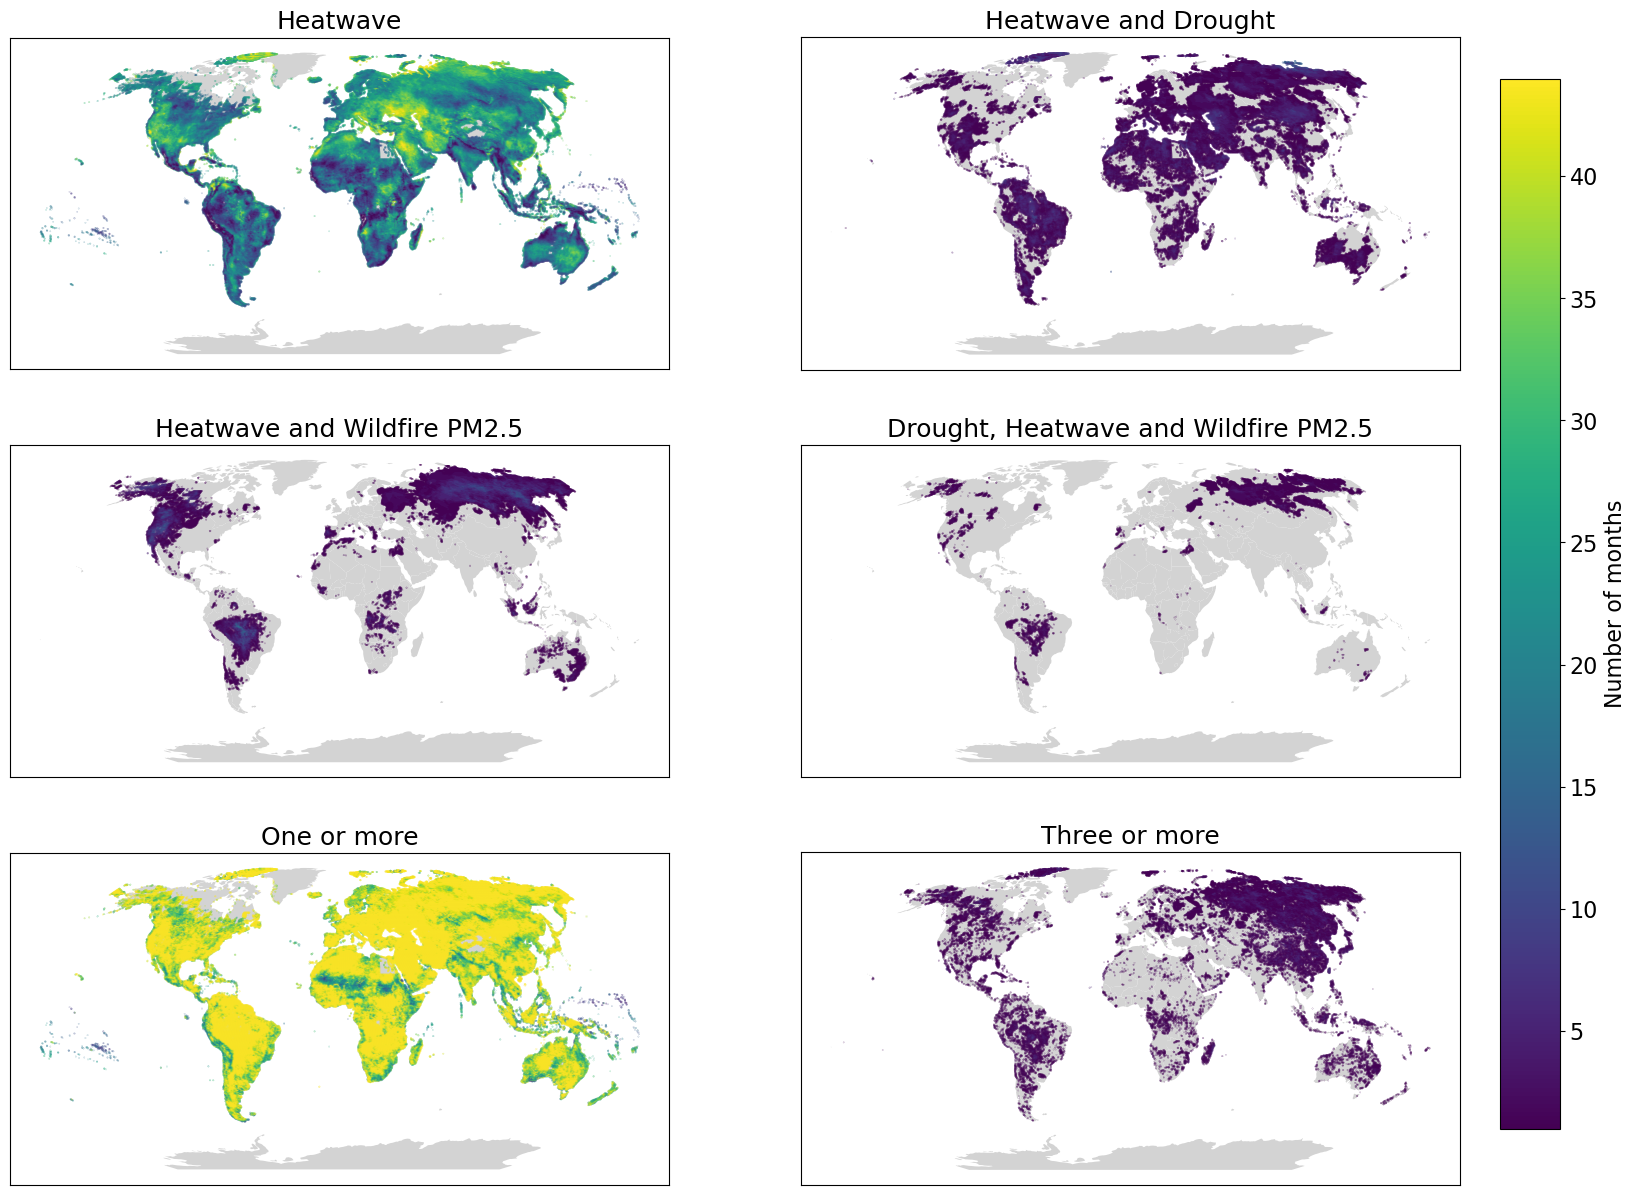

In [15]:
import copy
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from cartopy import crs
valid_combis = []
vmax_list = []
plt.rcParams.update({'font.size': 16})  # Adjust the font size as needed
title = {'HW': 'Heatwave', 'DR-HW':'Heatwave and Drought', 'HW-WF': 'Heatwave and Wildfire PM2.5', 'DR-HW-WF': 'Drought, Heatwave and Wildfire PM2.5', 'One or more':'One or more', 'Three or more':'Three or more'}

pair_tuple_keys = [key for key in imp_combined[age].keys() if len(key) == 5]

# Load a world map to use as a land mask
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
robinson = crs.Robinson().proj4_init
world = world.to_crs(robinson)

# Select six combinations to plot
combinations_to_plot = ['HW', 'DR-HW', 'HW-WF', 'DR-HW-WF', 'One or more', 'Three or more']  # Adjust as necessary to select the combinations you want

# Create a 3x2 grid for the plots
fig, axes = plt.subplots(3, 2, figsize=(20, 15), subplot_kw={'aspect': 'equal'})
axes = axes.flatten()

# Ensure the datasets 'One or more' and 'Three or more' are included
imp_combined[age]['Three or more'] = at_least_three_hazards[age]
imp_combined[age]['One or more'] = at_least_one_hazards[age]

vmax_global = 0

# First pass to determine global vmax
for combi in combinations_to_plot:
    gdf = imp_combined[age][combi]._build_exp().gdf
    imp_mat = copy.deepcopy(imp_combined[age][combi].imp_mat)
    imp_mat.data[imp_mat.data > 1] = 1
    imp_mat.data[imp_mat.data < 1] = 0


    gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]

    #gdf = gpd.GeoDataFrame(gdf, geometry=gpd.points_from_xy(gdf.longitude, gdf.latitude))

    
    # Determine dynamic vmax
    vmax_local = gdf['value'][gdf['value'] > 0].quantile(0.6)  # Set vmax to the 90th percentile of the data
    vmax_global = max(vmax_global, vmax_local)

# Second pass to plot the figures
for i, combi in enumerate(combinations_to_plot):
    ax = axes[i]
    gdf = imp_combined[age][combi]._build_exp().gdf
    imp_mat = copy.deepcopy(imp_combined[age][combi].imp_mat)
    imp_mat.data[imp_mat.data > 0] = 1

    gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]
    #gdf = gpd.GeoDataFrame(gdf, geometry=gpd.points_from_xy(gdf.longitude, gdf.latitude))
    # Plot the world map with only the land areas colored
    world.plot(ax=ax, color='lightgrey')
    
    # Set values of 0 to NaN for better plotting
    gdf.loc[gdf['value'] == 0, 'value'] = np.nan
    gdf.loc[gdf['value'] > 0, 'value'] = gdf.loc[gdf['value'] > 0, 'value'].astype(int)
    gdf.set_crs("epsg:4326", inplace=True)
    robinson = crs.Robinson().proj4_init
    gdf = gdf.to_crs(robinson)

    gdf.plot(column='value', ax=ax, markersize=0.01, cmap='viridis', vmin=1, vmax=vmax_global)
    
    # Set plot title and remove axis ticks
    ax.set_title(title[combi], fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])

# Create a shared color bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.03, 0.7])  # Adjust position as needed
norm = Normalize(vmin=1, vmax=vmax_global)
sm = ScalarMappable(cmap='viridis', norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Number of months')

# Save the figure
#plt.savefig(FIGURES / f"nmonth.pdf", bbox_inches='tight', dpi=400)


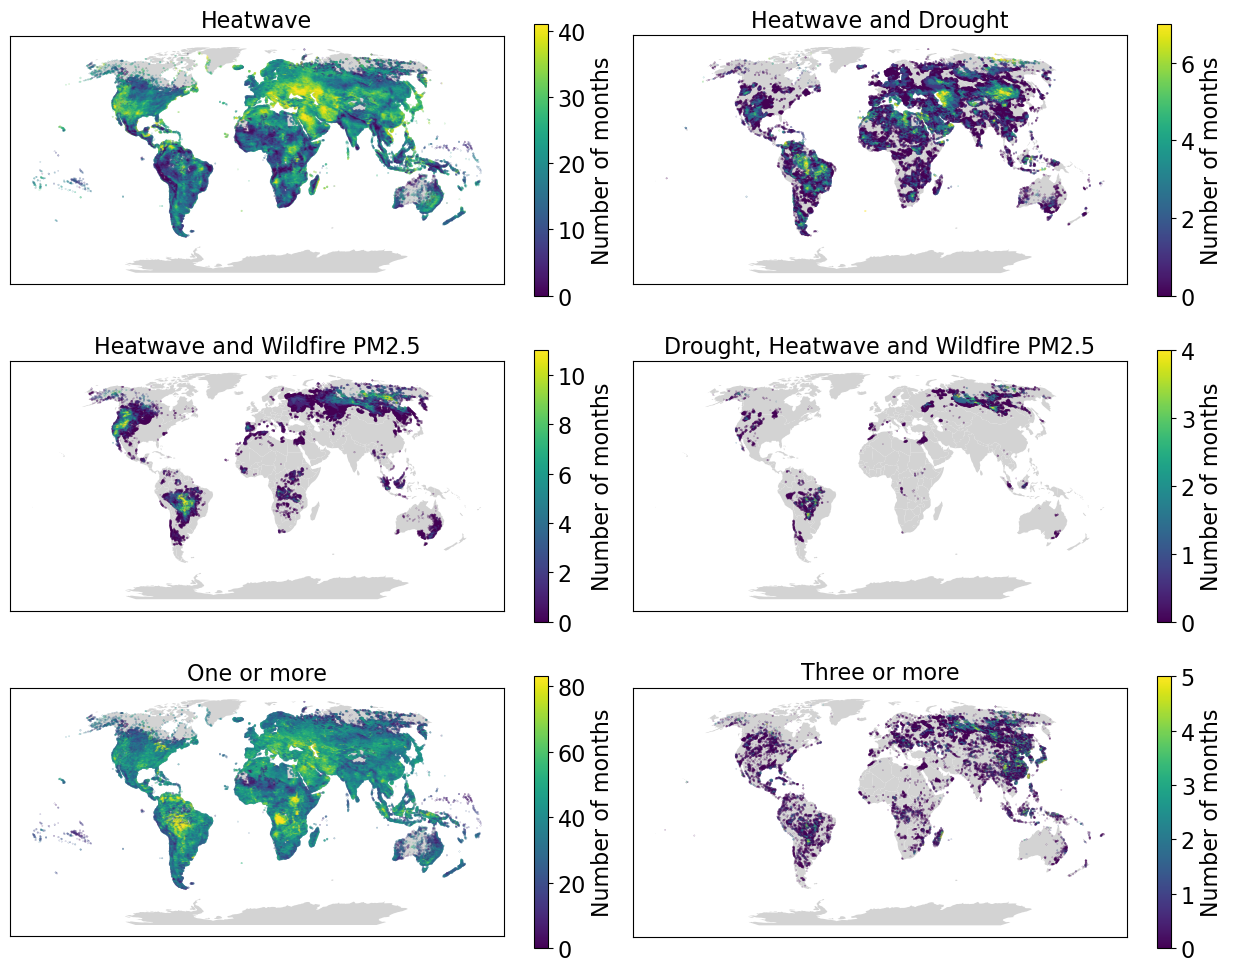

In [16]:
# Create a 3x2 grid for the plots
fig, axes = plt.subplots(3, 2, figsize=(16, 12), subplot_kw={'aspect': 'equal'})
axes = axes.flatten()

# Adjust the space between subplots
plt.subplots_adjust(wspace=0.01)  # Reduce this value to make the plots closer

# Ensure the datasets 'One or more' and 'Three or more' are included
imp_combined[age]['Three or more'] = at_least_three_hazards[age]
imp_combined[age]['One or more'] = at_least_one_hazards[age]

# Second pass to plot the figures and add colorbars
for i, combi in enumerate(combinations_to_plot):
    ax = axes[i]
    gdf = imp_combined[age][combi]._build_exp().gdf
    imp_mat = copy.deepcopy(imp_combined[age][combi].imp_mat)
    imp_mat.data[imp_mat.data < 1] = 0

    imp_mat.data[imp_mat.data >= 1] = 1

    gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]

    # Plot the world map with only the land areas colored
    world.plot(ax=ax, color='lightgrey')
    
    # Set values of 0 to NaN for better plotting
    gdf.loc[gdf['value'] == 0, 'value'] = np.nan
    gdf.loc[gdf['value'] > 0, 'value'] = gdf.loc[gdf['value'] > 0, 'value'].astype(int)
    gdf.set_crs("epsg:4326", inplace=True)
    robinson = crs.Robinson().proj4_init
    gdf = gdf.to_crs(robinson)

    # Calculate the 99th percentile for each combination
    vmax_local = gdf['value'][gdf['value'] > 0].quantile(0.99)
    
    # Plot the data
    gdf_plot = gdf.plot(column='value', ax=ax, markersize=0.01, cmap='viridis', vmin=1, vmax=vmax_local)
    
    # Set plot title and remove axis ticks
    ax.set_title(title[combi], fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar for each plot
    norm = Normalize(vmin=0, vmax=vmax_local)
    sm = ScalarMappable(cmap='viridis', norm=norm)
    sm._A = []  # Empty the array for the ScalarMappable (matplotlib expects this)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Number of months')

# Save the figure
plt.savefig(FIGURES / f"nmonth.pdf", bbox_inches='tight', dpi=400)
plt.show()


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/1625301063.py:14: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/1625301063.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


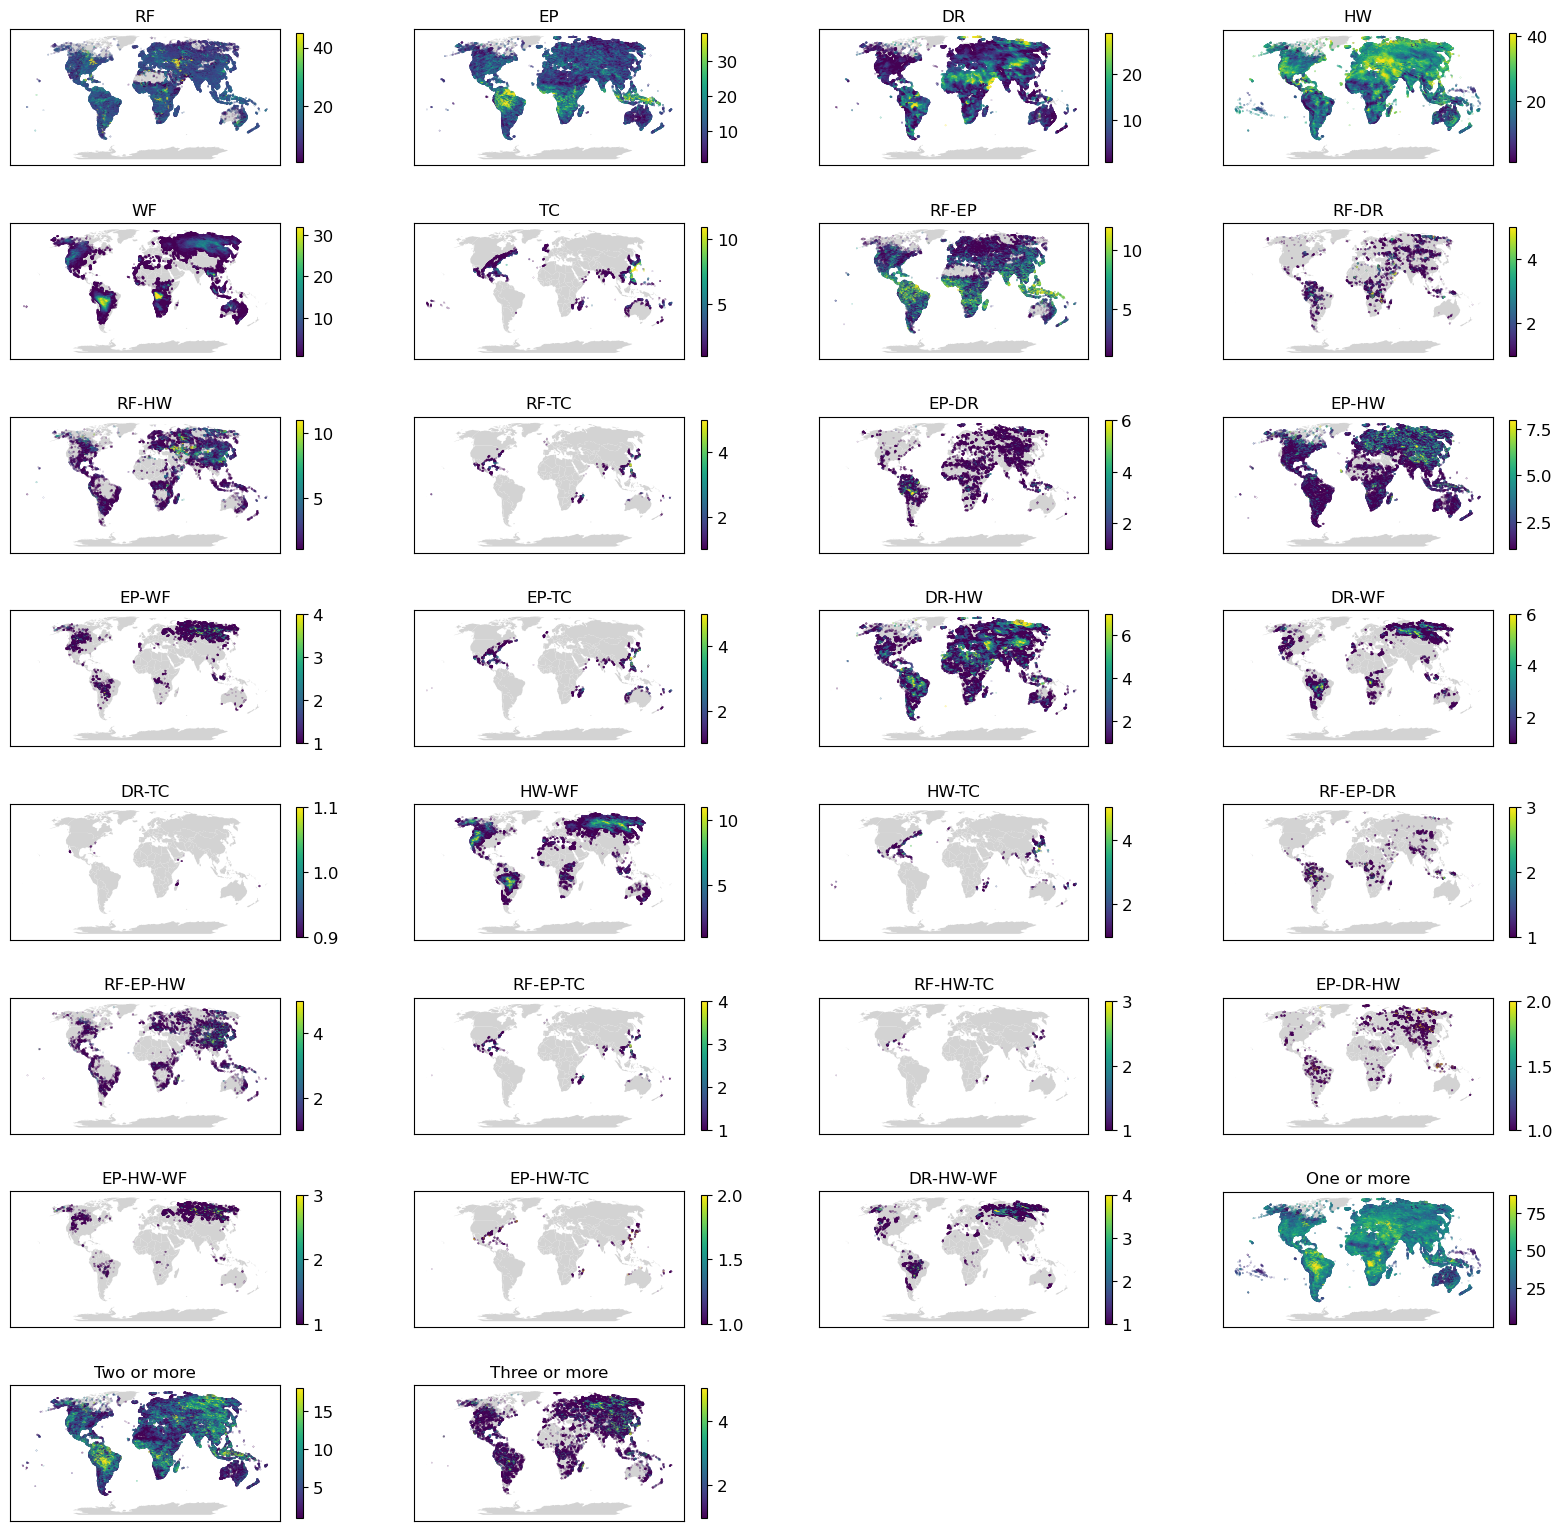

In [18]:
import copy
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from cartopy import crs

plt.rcParams.update({'font.size': 12})  # Adjust the size as needed

pair_tuple_keys = [key for key in imp_combined[age].keys() if len(key) == 5]

# Load a world map to use as a land mask
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filter combinations
filtered_combis = [combi for combi in imp_combined[age]]

# Create a figure with 8 rows and 4 columns, with reduced row spacing
fig, axes = plt.subplots(8, 4, figsize=(20, 20), gridspec_kw={'hspace': 0.05})  # Reduced hspace here
axes = axes.flatten()
r = 0
plots_created = 0
# Iterate over the valid combinations and plot
age = 'all'
imp_combined[age]['One or more'] = at_least_one_hazards[age]
imp_combined[age]['Two or more'] = at_least_two_hazards[age]
imp_combined[age]['Three or more'] = at_least_three_hazards[age]

gdf_dict = {}
for idx, combi in enumerate(imp_combined[age]):
    idx = idx - r
    # if combi in combinations_to_plot:
    #     r = r + 1
    #     continue

    if imp_combined['all'][combi].at_event.max() < 1e6:
        r = r + 1
        continue
    
    gdf = imp_combined[age][combi]._build_exp().gdf
    
    imp_mat = copy.deepcopy(imp_combined[age][combi].imp_mat)
    imp_mat.data[imp_mat.data < 1] = 0

    imp_mat.data[imp_mat.data >= 1] = 1

    gdf['value'] = np.asarray(imp_mat.sum(axis=0))[0]
        
    gdf['value'][gdf['value'] == 0] = np.nan
    robinson = crs.Robinson().proj4_init
    world = world.to_crs(robinson)
    world.plot(ax=axes[idx], color='lightgrey')
    gdf['value'][gdf['value'] > 0] = gdf['value'][gdf['value'] > 0].astype(int)
    gdf.set_crs("epsg:4326", inplace=True)
    gdf_dict[combi] = gdf
    gdf = gdf.to_crs(robinson)
    
    # Calculate the 99th percentile for each combination
    vmax_local = gdf['value'][gdf['value'] > 0].quantile(0.99)

    # Plot the data
    gdf.plot(column='value', ax=axes[idx], markersize=0.01, cmap='viridis', vmin=1, vmax=vmax_local)

    # Add a colorbar for each subplot
    norm = Normalize(vmin=1, vmax=vmax_local)
    sm = ScalarMappable(cmap='viridis', norm=norm)
    sm._A = []  # Empty the array for ScalarMappable (required by matplotlib)
    cbar = fig.colorbar(sm, ax=axes[idx], orientation='vertical', shrink=0.7)

    axes[idx].set_title(combi.replace("_2y", ""), fontsize=12)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])
    plots_created += 1
    
for ax in axes[plots_created:]:
    ax.set_visible(False)


# Adjust layout to reduce space between plots vertically
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)  # Adjust this value to reduce vertical space between rows

plt.savefig(FIGURES_SI / "nmonth_all.pdf", bbox_inches='tight', dpi=400)
plt.show()


In [20]:
gdf

,value,geometry
0,NaN,POINT (0.00000 -90.00000)
1,NaN,POINT (0.25000 -90.00000)
2,NaN,POINT (0.50000 -90.00000)
3,NaN,POINT (0.75000 -90.00000)
4,NaN,POINT (1.00000 -90.00000)
...,...,...
1038235,NaN,POINT (-1.25000 90.00000)
1038236,NaN,POINT (-1.00000 90.00000)
1038237,NaN,POINT (-0.75000 90.00000)
1038238,NaN,POINT (-0.50000 90.00000)


In [21]:
# Start with the first gdf as base
first_key = next(iter(gdf_dict))
combined_gdf = gdf_dict[first_key][['geometry']].copy()

# Loop through the dictionary
for combi, gdf in gdf_dict.items():
    if gdf is None or 'value' not in gdf.columns:
        continue
    
    # Rename 'value' column to combination name
    gdf_renamed = gdf[['geometry', 'value']].rename(columns={'value': combi})
    
    # Merge on geometry
    combined_gdf = combined_gdf.merge(gdf_renamed, on='geometry', how='outer')

# Fill any NaNs with 0
combined_gdf = combined_gdf.fillna(0)

# Drop rows where all values (excluding geometry) are 0
data_cols = combined_gdf.columns.difference(['geometry'])
combined_gdf = combined_gdf[~(combined_gdf[data_cols] == 0).all(axis=1)]


In [23]:
combined_gdf

,geometry,RF,EP,DR,HW,WF,TC,RF-EP,RF-DR,RF-HW,...,RF-EP-HW,RF-EP-TC,RF-HW-TC,EP-DR-HW,EP-HW-WF,EP-HW-TC,DR-HW-WF,One or more,Two or more,Three or more
197009,POINT (-67.75000 -56.00000),0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0
197010,POINT (-67.50000 -56.00000),0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0
197011,POINT (-67.25000 -56.00000),0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0
197012,POINT (-67.00000 -56.00000),0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0
198444,POINT (-69.00000 -55.75000),0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989517,POINT (59.25000 81.75000),0.0,0.0,36.0,14.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,1.0,0.0
989531,POINT (62.75000 81.75000),0.0,0.0,25.0,10.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,3.0,0.0
989532,POINT (63.00000 81.75000),0.0,0.0,21.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,2.0,0.0
989533,POINT (63.25000 81.75000),0.0,0.0,33.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,4.0,0.0


In [ ]:
combined_gdf.to_csv(DATA_DIR/"nmonth_combinations.csv")

In [ ]:
combined_gdf.plot("RF", markersize=0.1, vmax=gdf_dict['RF']['value'][gdf_dict['RF']['value'] > 0].quantile(0.99), legend=True)

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_62417/1328678827.py:12: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


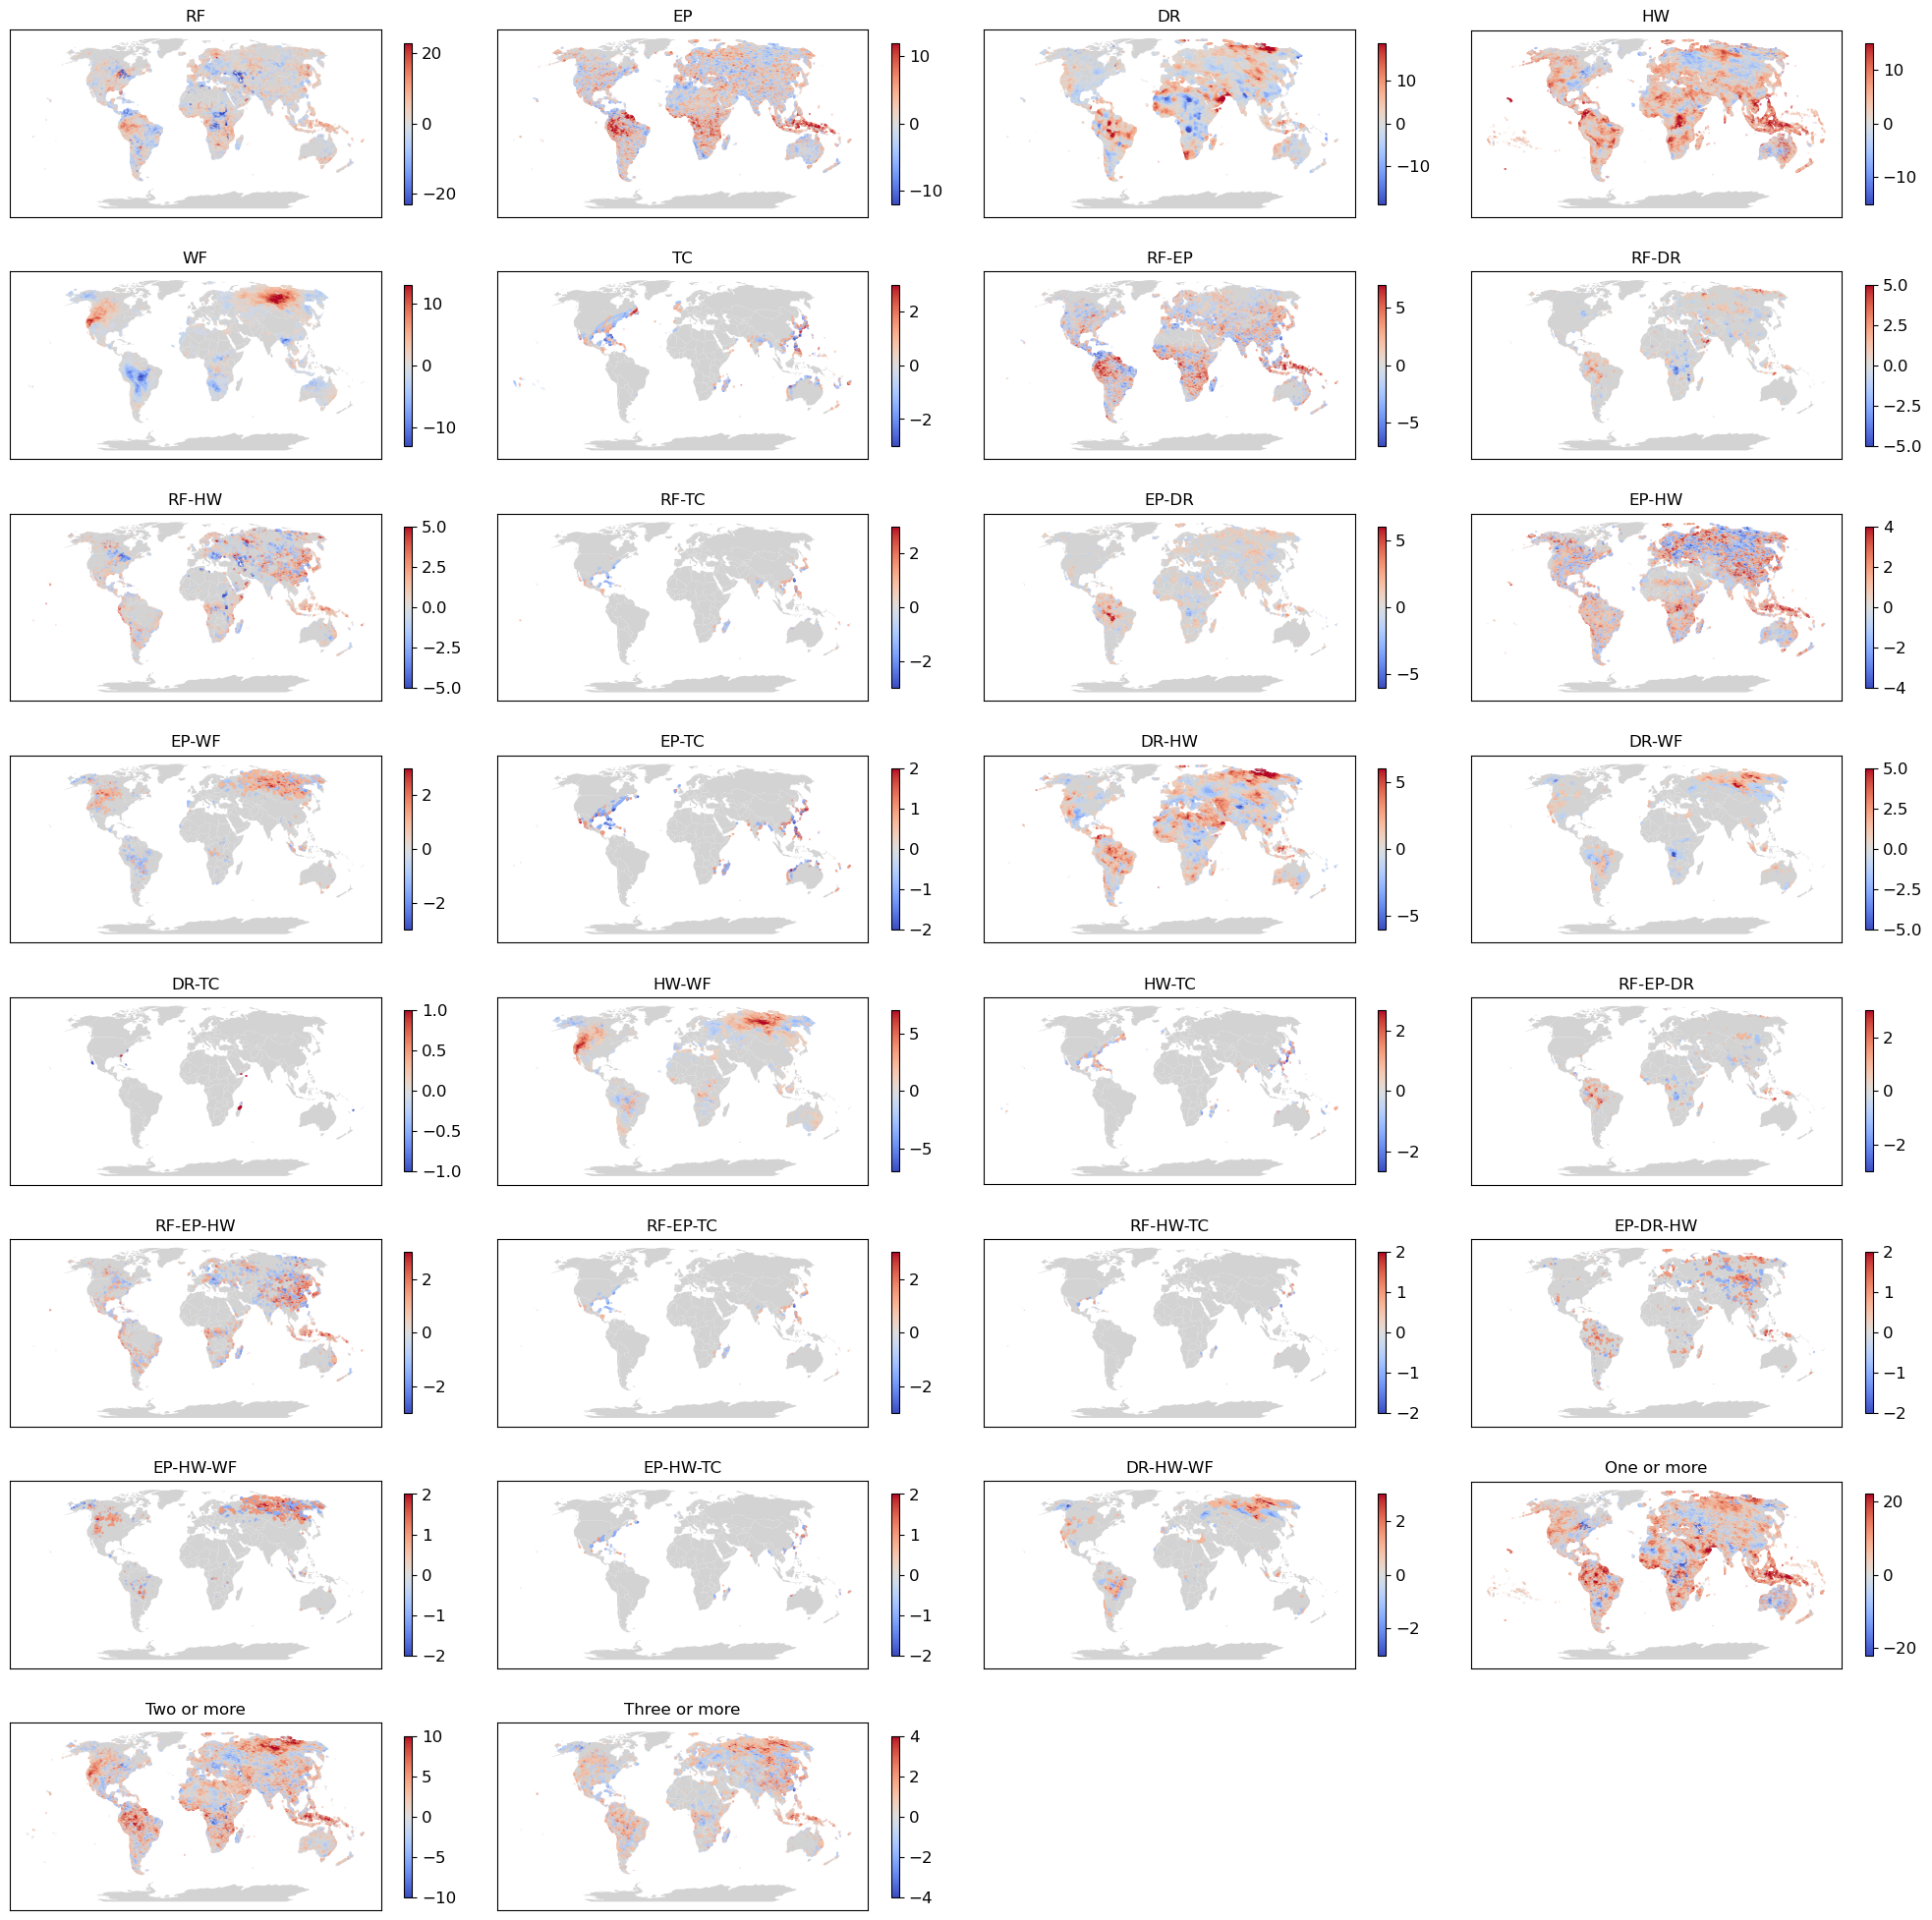

In [24]:
import copy
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from cartopy import crs

plt.rcParams.update({'font.size': 12})  # Adjust the size as needed

# Load a world map to use as a land mask
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Create a figure with 8 rows and 4 columns, with reduced row spacing
fig, axes = plt.subplots(8, 4, figsize=(20, 20))  # Reduced hspace here
axes = axes.flatten()
r = 0
plots_created = 0

# Iterate over the valid combinations and plot

imp_combined['all']['One or more'] = at_least_one_hazards[age]
imp_combined['all']['Two or more'] = at_least_two_hazards[age]
imp_combined['all']['Three or more'] = at_least_three_hazards[age]
for idx, combi in enumerate(imp_combined['all']):
    idx = idx - r
 
    if imp_combined['all'][combi].at_event.max() < 1e6:
        r = r + 1
        continue
    
    gdf = imp_combined['all'][combi]._build_exp().gdf
    gdf['longitude'] = gdf.geometry.x
    gdf['latitude'] = gdf.geometry.y
    imp_mat = copy.deepcopy(imp_combined['all'][combi].imp_mat)
    imp_mat.data[imp_mat.data < 1] = 0
    imp_mat.data[imp_mat.data >= 1] = 1

    # Calculate the difference between the first period (2003-2012) and the second period (2013-2021)
    gdf['value'] = np.asarray(imp_mat[108:].sum(axis=0) - imp_mat[0:120].sum(axis=0))[0]
    
    gdf = gpd.GeoDataFrame(gdf, geometry=gpd.points_from_xy(gdf.longitude, gdf.latitude))
    robinson = crs.Robinson().proj4_init
    world = world.to_crs(robinson)
    world.plot(ax=axes[idx], color='lightgrey')
    gdf = gdf[gdf.value!=0]
    if len(gdf)<100:
        continue
    gdf.set_crs("epsg:4326", inplace=True)
    gdf = gdf.to_crs(robinson)
    
    # Calculate the 99th percentile for the colorbar limit
    vmax_local = np.quantile(gdf['value'],0.99)
    vmin_local = np.quantile(gdf['value'],0.01)
    vmin_abs = abs(vmin_local)
    vmax = np.max([vmin_abs,vmax_local])
    if vmax==0:
        continue


    # Plot the data using the 'coolwarm' colormap, which has blue for negative values and red for positive values
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    gdf.plot(column='value', ax=axes[idx], markersize=0.01, cmap='coolwarm', norm=norm)

    # Add a colorbar for each subplot
    sm = ScalarMappable(cmap='coolwarm', norm=norm)
    sm._A = []  # Empty the array for ScalarMappable (required by matplotlib)
    cbar = fig.colorbar(sm, ax=axes[idx], orientation='vertical', shrink=0.7)
    #Ecbar.set_label('Difference', fontsize=12)

    axes[idx].set_title(combi.replace("_2y", ""), fontsize=12)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])
    plots_created += 1

# Hide any remaining unused subplots
for ax in axes[plots_created:]:
    ax.set_visible(False)

# Adjust layout to reduce space between plots vertically
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig(FIGURES_SI / "nmonth_change.pdf", bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
imp_combined['all']

In [ ]:
np.maxvmax_local

In [ ]:
imp_combined[age][combi].imp_mat[108:]

In [ ]:
combined_gdf.drop